In [6]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms.functional as F
from typing import Tuple, Union, List
import time
import torch.nn.functional as f
import matplotlib.pyplot as plt

In [7]:
class Physics():
    def __init__(self,mag = 1,min_angle = -3.232,max_angle = 3.232):
        self.source_mag = mag
        self.min_angle = min_angle
        self.max_angle = max_angle
        
    #def sersic_fit(self,reconstructed_source):



    def image_to_source(self, image, centre=None, E_r=None, deflection=None, gradient=None):
        """
        Differentiable Lens Inversion. 
        Handles both NumPy and PyTorch Tensor inputs.
        """
        # 1. Convert NumPy input to PyTorch Tensor if necessary
        is_numpy = isinstance(image, np.ndarray)
        if is_numpy:
            image = torch.from_numpy(image).float()
        
        # Use the image's device (CPU or GPU)
        device = image.device
    
        # 2. Ensure image is 4D (B, C, H, W) for grid_sample
        if image.dim() == 2:
            image = image.unsqueeze(0).unsqueeze(0) # [H, W] -> [1, 1, H, W]
        elif image.dim() == 3:
            image = image.unsqueeze(0)             # [C, H, W] -> [1, C, H, W]
            
        B, C, H, W = image.shape
        
        # Calculate dimensions of the output source image based on magnification
        out_h, out_w = int(H * self.source_mag), int(W * self.source_mag)
        
        # 3. Create a coordinate grid for the SOURCE plane (Beta)
        y_range = torch.linspace(self.min_angle, self.max_angle, out_h, device=device)
        x_range = torch.linspace(self.min_angle, self.max_angle, out_w, device=device)
        theta_y, theta_x = torch.meshgrid(y_range, x_range, indexing='ij')
    
        # 4. Handle the Centre shift
        if centre is not None:
            # If centre is a list/tuple/ndarray, convert to tensor
            if not isinstance(centre, torch.Tensor):
                centre = torch.tensor(centre, device=device)
            
            pixel_to_angle = (self.max_angle - self.min_angle) / H
            c_y = self.min_angle + centre[0] * pixel_to_angle
            c_x = self.min_angle + centre[1] * pixel_to_angle
            rel_y = theta_y - c_y
            rel_x = theta_x - c_x
        else:
            rel_y, rel_x = theta_y, theta_x
    
        # Distance from centre
        r = torch.sqrt(rel_x**2 + rel_y**2) + 1e-8
    
        # 5. Calculate Deflection (Alpha)
        if deflection is not None:
            if not isinstance(deflection, torch.Tensor):
                deflection = torch.tensor(deflection, device=device)
            alpha_y = (deflection * rel_y) / r
            alpha_x = (deflection * rel_x) / r
        elif gradient is not None:
            if not isinstance(gradient, torch.Tensor):
                gradient = torch.tensor(gradient, device=device)
            # torch.gradient returns a list of tensors
            grad = torch.gradient(gradient)
            alpha_y, alpha_x = grad[0], grad[1]
        elif E_r is not None:
            # If E_r is a scalar (like E_r=1), convert to tensor
            if not isinstance(E_r, torch.Tensor):
                E_r = torch.tensor(E_r, device=device, dtype=torch.float32)
            
            # Simple SIS model: alpha = E_r
            alpha_y = (E_r * rel_y) / r
            alpha_x = (E_r * rel_x) / r
        else:
            raise ValueError("Both deflection and gradient cannot be None")
    
        # 6. Lens Equation: Beta = Theta - Alpha -> Theta = Beta + Alpha
        source_theta_y = theta_y + alpha_y
        source_theta_x = theta_x + alpha_x
    
        # 7. Normalize coordinates to [-1, 1] for grid_sample
        norm_x = 2 * (source_theta_x - self.min_angle) / (self.max_angle - self.min_angle) - 1
        norm_y = 2 * (source_theta_y - self.min_angle) / (self.max_angle - self.min_angle) - 1
    
        # 8. Stack and Sample
        grid = torch.stack((norm_x, norm_y), dim=-1)
        
        # Ensure grid matches batch size
        if grid.dim() == 3:
            grid = grid.unsqueeze(0).expand(B, -1, -1, -1)
    
        # mode='bilinear' makes the physics differentiable!
        sourceimage = f.grid_sample(image, grid, 
                                    mode='bilinear', 
                                    padding_mode='zeros', 
                                    align_corners=True)
    
        # 9. Return result
        # If input was NumPy, return NumPy. If it was Tensor, return Tensor.
        if is_numpy:
            return sourceimage.squeeze().detach().cpu().numpy()
        else:
            return sourceimage.squeeze()

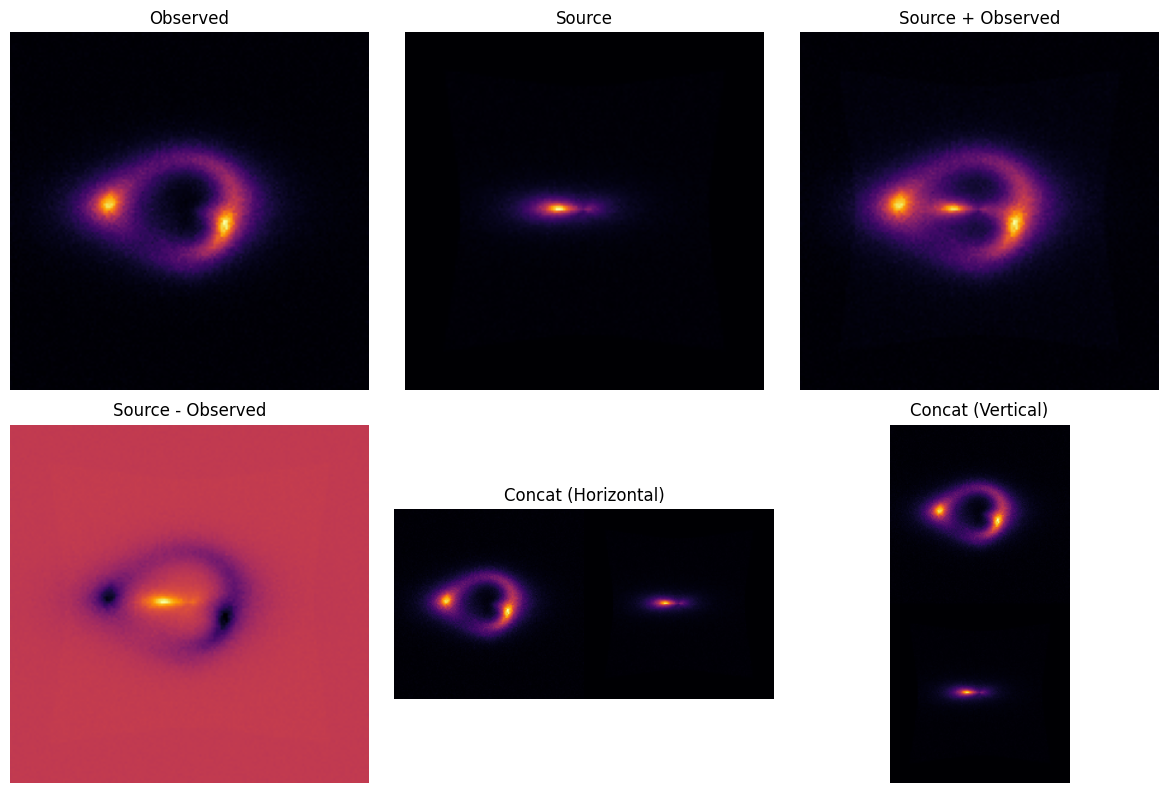

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
image = np.load("/kaggle/input/datasets/saxenaitis/deeplensetask0/dataset/train/vort/10.npy", allow_pickle=True)[0]

phy = Physics()
source = phy.image_to_source(image, E_r=1)

# Ensure same shape (important)
assert image.shape == source.shape, "Shapes must match"

# Operations
add_img = source + image
sub_img = source - image

# Concatenations
concat_h = np.concatenate((image, source), axis=1)  # side by side
concat_v = np.concatenate((image, source), axis=0)  # top-bottom

# Plot
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

axs[0, 0].imshow(image, cmap="inferno")
axs[0, 0].set_title("Observed")

axs[0, 1].imshow(source, cmap="inferno")
axs[0, 1].set_title("Source")

axs[0, 2].imshow(add_img, cmap="inferno")
axs[0, 2].set_title("Source + Observed")

axs[1, 0].imshow(sub_img, cmap="inferno")
axs[1, 0].set_title("Source - Observed")

axs[1, 1].imshow(concat_h, cmap="inferno")
axs[1, 1].set_title("Concat (Horizontal)")

axs[1, 2].imshow(concat_v, cmap="inferno")
axs[1, 2].set_title("Concat (Vertical)")

# Remove axes for clean look
for ax in axs.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()